<a href="https://colab.research.google.com/github/vennelanalajam/myproject/blob/main/Home_Lone_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Statement : Home Loan Default Prediction


# 🏦 Home Loan Default Prediction

# Objective
The goal of this project is to analyze customer data and build a predictive model to identify whether a customer is likely to default on a home loan.

# Business Problem
Banks face financial losses when customers fail to repay loans. By predicting potential defaulters in advance, banks can:
- Reduce risk
- Improve loan approval decisions
- Identify high-risk customer segments

# ML Problem
This is a binary classification problem :
- 1 → Defaulter
- 0 → Non-Defaulter

# Step 1 : Problem statement
The goal of this project is to analyze customer data and build a predictive model to identify whether a customer is likely to default on a home loan.


# Step 2 : Import Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# Step 3 : Load Dataset
We load the main dataset containing customer information and loan details.

In [17]:
df = pd.read_csv("/content/application_train.csv")
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


# Step 4 : Basic Checks

In [18]:
df.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0


In [19]:
df.shape

(307511, 122)

In [20]:
df.columns

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [22]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [23]:
df.isnull().sum()

,0
SK_ID_CURR,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
...,...
AMT_REQ_CREDIT_BUREAU_DAY,41519
AMT_REQ_CREDIT_BUREAU_WEEK,41519
AMT_REQ_CREDIT_BUREAU_MON,41519
AMT_REQ_CREDIT_BUREAU_QRT,41519


In [24]:
df.duplicated().sum()

np.int64(0)

# Step 5 : Target Variable Analysis
We analyze the distribution of defaulters vs non-defaulters.

In [25]:
df["TARGET"].value_counts()
df['TARGET'].value_counts(normalize=True)

,proportion
TARGET,
0,0.919271
1,0.080729


Insight:
- The dataset is imbalanced
- Fewer defaulters compared to non-defaulters

# Step 6 : Missing Value Treatment
We identify and handle missing values to improve data quality.

In [26]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing.head(10)

,0
COMMONAREA_AVG,214865
COMMONAREA_MODE,214865
COMMONAREA_MEDI,214865
NONLIVINGAPARTMENTS_MEDI,213514
NONLIVINGAPARTMENTS_MODE,213514
NONLIVINGAPARTMENTS_AVG,213514
FONDKAPREMONT_MODE,210295
LIVINGAPARTMENTS_AVG,210199
LIVINGAPARTMENTS_MEDI,210199
LIVINGAPARTMENTS_MODE,210199


Drop high missing columns

In [27]:
threshold = 0.5 * len(df)
df = df.dropna(thresh=threshold, axis=1)

Fill remaining values

In [28]:
for col in df.select_dtypes(include='number'):
    df[col].fillna(df[col].median(), inplace=True)

for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

# Step 7 : Exploratory Data Analysis (EDA)

We explore relationships between features and loan default.

Income vs Default

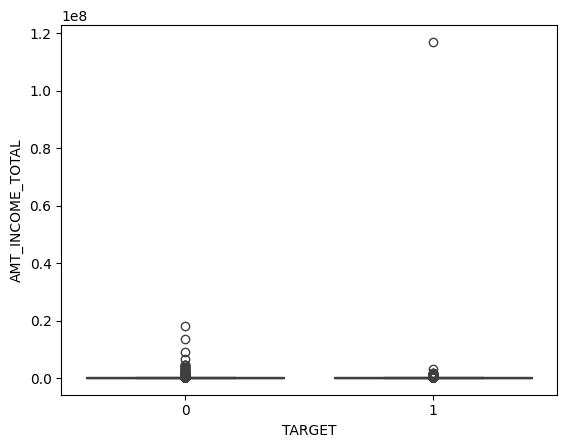

In [29]:
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=df)
plt.show()

Credit vs Default

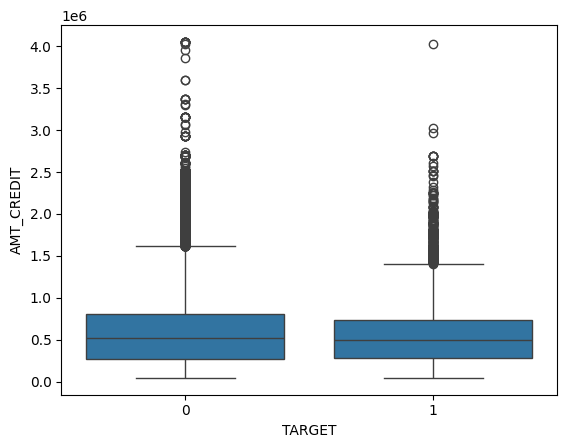

In [30]:
sns.boxplot(x='TARGET', y='AMT_CREDIT', data=df)
plt.show()

Insights:
- Customers with lower income tend to default more
- Higher credit amount may increase risk

# Step 8 : Feature Engineering
We create new features to improve model performance.

In [31]:
df['income_credit_ratio'] = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']
df['annuity_income_ratio'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

# Step 9 : Encoding Categorical Variables
Convert categorical variables into numerical format.

In [32]:
df = pd.get_dummies(df, drop_first=True)

# Step 10 : Train-Test Split
We split data into training and testing sets.

In [33]:
X = df.drop('TARGET', axis=1)
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 11 : Handle Imbalanced Data
We use SMOTE to balance the dataset.

In [34]:
sm = SMOTE()
X_train, y_train = sm.fit_resample(X_train, y_train)

# Step 12 : Model Building
We train multiple models and compare their performance.

Logistic Regression

In [35]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Decision Tree

In [36]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

Random Forest

In [37]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

# Step 13 : Model Evaluation
We evaluate models using classification metrics and ROC-AUC.

In [38]:
def evaluate(model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

In [39]:
print("Logistic Regression")
evaluate(lr)

print("Decision Tree")
evaluate(dt)

print("Random Forest")
evaluate(rf)

Logistic Regression
              precision    recall  f1-score   support

           0       0.93      0.73      0.82     56538
           1       0.11      0.37      0.17      4965

    accuracy                           0.70     61503
   macro avg       0.52      0.55      0.49     61503
weighted avg       0.86      0.70      0.76     61503

ROC-AUC: 0.5789750724917715
Decision Tree
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     56538
           1       0.13      0.18      0.15      4965

    accuracy                           0.84     61503
   macro avg       0.53      0.54      0.53     61503
weighted avg       0.86      0.84      0.85     61503

ROC-AUC: 0.5372612639532656
Random Forest
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.22      0.01      0.03      4965

    accuracy                           0.92     61503
   macro avg       0.57 

# Step 14 : Model Comparison
We compare models based on ROC-AUC score.

In [40]:
results = pd.DataFrame({
    'Model': ['Logistic', 'Decision Tree', 'Random Forest'],
    'ROC-AUC': [
        roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, dt.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])
    ]
})

results

,Model,ROC-AUC
0,Logistic,0.578975
1,Decision Tree,0.537261
2,Random Forest,0.690238


# Step 15 : Feature Importance
We identify the most important features influencing loan default.

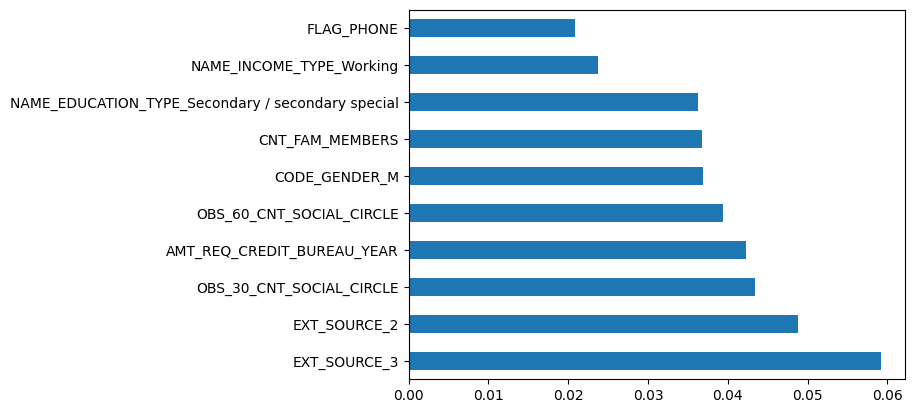

In [41]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh')
plt.show()

# Step 16 : Business Insights
 Key Insights

- Customers with high loan amount and low income are more likely to default
- High annuity to income ratio indicates financial stress
- Past financial behavior strongly impacts loan repayment ability

# Step 17 : Conclusion
Random Forest performed best based on ROC-AUC
- The model can help banks identify high-risk customers
- Loan approval decisions can be improved using this model

# Step 18 : Challenges Faced
- Large dataset with many missing values
- Imbalanced target variable
- High dimensionality after encoding
- Feature selection complexity